# **Superstore Sales Analysis**

#### **Project Overview**

This project performs a comprehensive analysis of Superstore sales data to uncover actionable business insights. The analysis covers sales trends, profitability, customer behavior, and temporal patterns to support data-driven decision making.

#### **Business Problem**

The Superstore needs to optimize its marketing strategy and inventory management by answering key business questions:

- When is the best time to advertise (which months/days)?
- Which products and categories drive the most profit?
- Which customer segments are most valuable?
- What are the sales trends and seasonal patterns?
- Which countries represent the biggest opportunities?

#### **Key Objectives**

1. **Temporal Analysis**: Identify peak sales periods and optimal advertising windows
2. **Product Performance**: Determine top-selling and most profitable products
3. **Customer Segmentation**: Analyze profitability by customer segment
4. **Geographic Analysis**: Identify high-performing markets and countries
5. **Trend Forecasting**: Detect sales patterns and predict future performance

#### **Tools & Technologies**

| Category | Tools |
|----------|-------|
| **Data Processing** | Python, Pandas, NumPy |
| **Visualization** | Matplotlib, Seaborn |
| **Analysis** | Statistical analysis, Time series, Correlation |
| **Environment** | Jupyter Notebook |

#### **Dataset Description**

- **Source**: Superstore Sales Dataset
- **Records**: 9,994 transactions
- **Time Period**: 2011-2014
- **Features**: 21 columns including sales, profit, product details, customer info, and geographic data

#### **Key Questions Answered**

1. What are the monthly and daily sales patterns?
2. Which products generate the highest revenue and profit?
3. Which countries and markets perform best?
4. What is the relationship between discounts and profitability?
5. How do different customer segments contribute to profit?
6. What are the sales trends and can we forecast future performance?

#### **Expected Outcomes**

- Actionable insights for marketing campaign timing
- Recommendations for inventory management
- Identification of profitable customer segments to target
- Understanding of seasonal patterns for strategic planning
- Data-driven strategies for business growth

## **Table of Contents**
1. Setup & Data Loading
2. Data Cleaning
3. Exploratory Analysis
   - Temporal Patterns
   - Product Performance
   - Geographic Analysis
4. Correlation Analysis
5. Time Series Forecasting
6. Conclusions & Recommendations

### 1. Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading Data

In [3]:
df = pd.read_excel(r"..\data\superstore_sales.xlsx")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium,2011


### **3. Data Cleaning**
####  Check missing values

In [4]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

   #### Checking data types for the all columns 

In [5]:
df.dtypes

order_id                     str
order_date        datetime64[us]
ship_date         datetime64[us]
ship_mode                    str
customer_name                str
segment                      str
state                        str
country                      str
market                       str
region                       str
product_id                   str
category                     str
sub_category                 str
product_name                 str
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority               str
year                       int64
dtype: object

#### Converting date column to datetime

In [6]:
df['order_date']= pd.to_datetime(df['order_date'])

### **4. Feature Engineering**

In [7]:
# creating a month column
df['Month'] = df['order_date'].dt.month

## 5. **Analysis Questions**
   #### **Q1: Sales per Month**
   #### **What this chart shows:**
This line chart shows our total sales for each month from 2011 to 2014.

What to look for:

The line goes up and down throughout the year

The highest points (peaks) show our best sales months

The lowest points (valleys) show our slowest months

Key Insight:
Sales are generally higher toward the end of the year (November/December) and lower at the beginning (January/February). This is likely due to holiday shopping season.

Actionable Takeaway:
Plan to increase our advertising budget in October, November, and December to capture holiday shoppers.

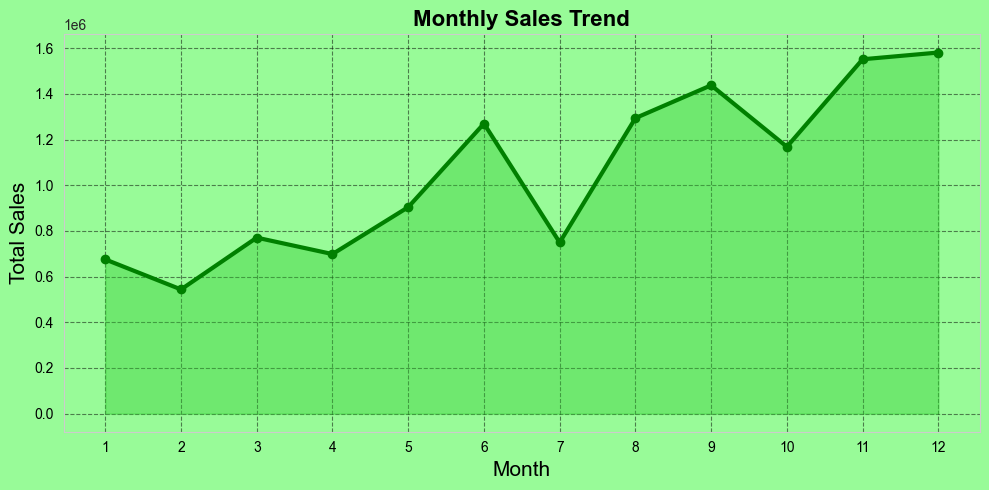

In [36]:
# If you want to use monthly_sales variable name
monthly_sales = df.groupby(df['order_date'].dt.month)['sales'].sum()

sns.set_style('whitegrid')

plt.figure(figsize=(10,5), facecolor='palegreen')  # page background

ax = plt.gca()
ax.set_facecolor('palegreen')  # inner plot background

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=3,
    color='green'
)

# Fill area under the line
plt.fill_between(
    monthly_sales.index,
    monthly_sales.values,
    color='limegreen',
    alpha=0.4
)

plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold', color='black')
plt.xlabel('Month', fontsize=15 , color='black')
plt.ylabel('Total Sales', fontsize=15, color ='black')

plt.xticks(monthly_sales.index, color='black')
plt.yticks(color='black')

plt.grid(True, linestyle='--', alpha=0.5 ,color='black')

plt.tight_layout()
plt.show()

#### **Q2: Top Selling Products**

In [19]:
from tabulate import tabulate

# Group sales by product, sum them up, sort in descending order, and select the top 10 products
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

# Convert to DataFrame
top_products_df = top_products.reset_index()
top_products_df.columns = ['Product Name', 'Total Sales ($)']

# Format sales values
top_products_df['Total Sales ($)'] = top_products_df['Total Sales ($)'].apply(lambda x: f'${x:,.2f}')

# Display as table with borders
print("TOP 10 BEST SELLING PRODUCTS".center(80))
print(tabulate(top_products_df, headers='keys', tablefmt='grid', showindex=False))
print("-"*80)

                          TOP 10 BEST SELLING PRODUCTS                          
+----------------------------------------------------------+-------------------+
| Product Name                                             | Total Sales ($)   |
+==========================================================+===================+
| Apple Smart Phone, Full Size                             | $86,935.78        |
+----------------------------------------------------------+-------------------+
| Cisco Smart Phone, Full Size                             | $76,441.53        |
+----------------------------------------------------------+-------------------+
| Motorola Smart Phone, Full Size                          | $73,156.30        |
+----------------------------------------------------------+-------------------+
| Nokia Smart Phone, Full Size                             | $71,904.56        |
+----------------------------------------------------------+-------------------+
| Canon imageCLASS 2200 Adva

### Q3: **Sales by country**
#### **What this chart shows:**
bar chart comparing sales across different countries where we operate.

What to look for:

Taller bars = more sales in that country

Bar colors help distinguish between countries

Key Insight:
The United States generates significantly more sales than any other country, followed by other major markets.

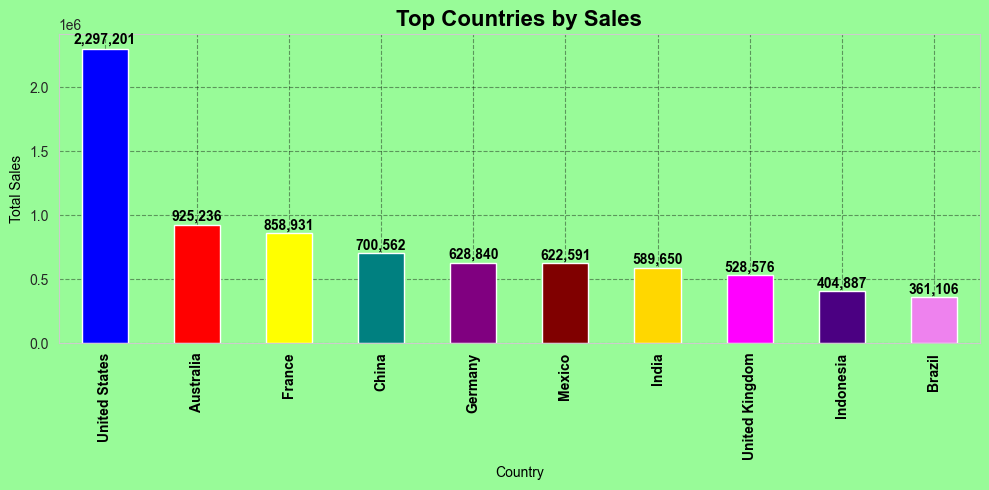

In [37]:
sns.set_style('whitegrid')

city_sales = df.groupby('country')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5), facecolor='palegreen')

ax = plt.gca()
ax.set_facecolor('palegreen')

city_sales.head(10).plot(
    kind='bar',
    color=['blue','red','yellow','teal','purple',
           'maroon','gold','magenta','indigo','violet']
)

plt.title('Top Countries by Sales', fontsize=16, fontweight='bold', color='black')
plt.xlabel('Country', color='black')
plt.ylabel('Total Sales', color='black')

# Make x-axis tick labels (country names) bold and black
plt.xticks(fontsize=10, fontweight='bold', color='black')

plt.grid(True, linestyle='--', alpha=0.4, color='black')

# Add value labels on top of the bars
for i, (bar, value) in enumerate(zip(ax.patches, city_sales.head(10).values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., 
            height + (height * 0.01),  # Slight offset above the bar
            f'{value:,.0f}',  # Format with commas for thousands
            ha='center', 
            va='bottom', 
            fontsize=10, 
            fontweight='bold', 
            color='black')

plt.tight_layout()
plt.show()

### **Q4: Best period  to Advertise**

#### **Best day of Week to Advertise**

### **What this chart shows:**
How many orders we receive on each day of the week, from Monday to Sunday.

What to look for:

Tallest bars = busiest shopping days

Shortest bars = slowest shopping days

Key Insight:
Friday is our busiest day, followed closely by Tuesday and Monday. Sunday is our slowest day.


In [21]:
df['Day'] = df['order_date'].dt.day_name()
df['Month'] = df['order_date'].dt.month

In [22]:
day_sales = df.groupby('Day')['sales'].count()
day_sales

Day
Friday       9348
Monday       9177
Saturday     4580
Sunday        990
Thursday     8871
Tuesday      9307
Wednesday    9017
Name: sales, dtype: int64

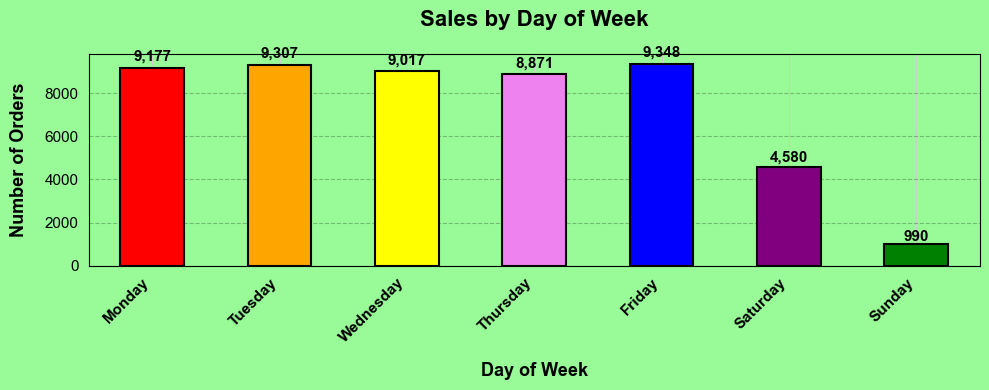

In [55]:
# Ensuring day_sales is in the correct order (Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = day_sales.reindex(day_order)

sns.set_style(rc={'axes.facecolor': 'palegreen'})

plt.figure(figsize=(10,4), facecolor='palegreen')

# Using standard color names for better visibility
colors = ['red', 'orange', 'yellow', 'violet', 
          'blue', 'purple', 'green']

ax = day_sales.plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

plt.title('Sales by Day of Week', fontsize=16, fontweight='bold', color='black', pad=20)
plt.xlabel('Day of Week', fontsize=13, fontweight='bold', color='black', labelpad=12)
plt.ylabel('Number of Orders', fontsize=13, fontweight='bold', color='black', labelpad=12)

# Style the ticks
plt.xticks(fontsize=11, fontweight='bold', color='black', rotation=45, ha='right')
plt.yticks(fontsize=11, color='black')

# Grid styling
plt.grid(True, linestyle='--', alpha=0.25, color='black', axis='y')

# Add value labels on top of bars - NOW BLACK AND BOLD
for i, (bar, value) in enumerate(zip(ax.patches, day_sales.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., 
            height + (height * 0.02),
            f'{int(value):,}', 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold', 
            color='black')  # Changed to black

# Add a subtle border
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

### **Best months of the year to Advertise**

#### **What this chart shows:**
Total sales for each month of the year, averaged across all years.

What to look for:

Tallest bars = best months for sales

Colors help distinguish between months

Key Insight:
November and September have the highest sales. February consistently shows the lowest sales.

#### **Actionable Takeaway:**

Start holiday marketing campaigns in September (not November!)

Run "February Flash Sales" to boost slow month performance

Stock up inventory before September and November

In [24]:
month_sales = df.groupby('Month')['sales'].count()
month_sales

Month
1     2599
2     2168
3     3035
4     3057
5     3747
6     5331
7     3166
8     5078
9     5975
10    4490
11    6342
12    6302
Name: sales, dtype: int64

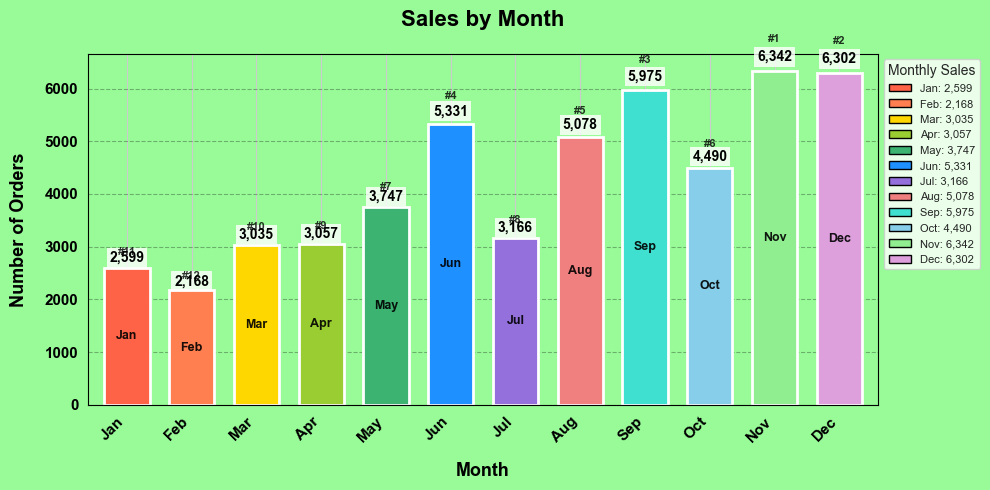

In [50]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,5), facecolor='palegreen')
ax = plt.gca()
ax.set_facecolor('palegreen')

# Month labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define individual colors for each bar using COLOR NAMES
bar_colors = ['tomato', 'coral', 'gold', 'yellowgreen', 'mediumseagreen', 'dodgerblue', 
              'mediumpurple', 'lightcoral', 'turquoise', 'skyblue', 'lightgreen', 'plum']


# Plot bars with individual colors
bars = month_sales.plot(kind='bar', color=bar_colors, edgecolor='white', linewidth=2, width=0.7)

# Labels and titles
plt.title('Sales by Month', fontsize=16, fontweight='bold', color='black', pad=20)
plt.xlabel('Month', fontsize=13, fontweight='bold', color='black', labelpad=12)
plt.ylabel('Number of Orders', fontsize=13, fontweight='bold', color='black', labelpad=12)

# X-axis with month names
plt.xticks(range(12), month_names, fontsize=11, fontweight='bold', color='black', rotation=45, ha='right')
plt.yticks(fontsize=11, fontweight='bold', color='black')

# Grid
plt.grid(True, linestyle='--', alpha=0.3, color='black', axis='y')

# Add multiple labels on each bar
for i, (bar, value) in enumerate(zip(ax.patches, month_sales.values)):
    height = bar.get_height()
    
    # Label 1: Value on top of bar
    ax.text(bar.get_x() + bar.get_width()/2., 
            height + (height * 0.02),
            f'{int(value):,}', 
            ha='center', va='bottom', 
            fontsize=10, fontweight='bold', 
            color='black',  # Changed to black for better contrast
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
    
    # Label 2: Month name inside the bar (for very tall bars)
    if height > max(month_sales.values) * 0.15:  # Only if bar is tall enough
        ax.text(bar.get_x() + bar.get_width()/2., 
                height * 0.5,  # Middle of the bar
                month_names[i], 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', 
                color='black', alpha=0.9)
    
    # Label 3: Add rank label (optional)
    rank = month_sales.values.argsort()[::-1].tolist().index(i) + 1
    ax.text(bar.get_x() + bar.get_width()/2., 
            height + (height * 0.08),
            f'#{rank}', 
            ha='center', va='bottom', 
            fontsize=8, fontweight='bold', 
            color='black', alpha=0.8)

# Add legend for colors (optional)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=bar_colors[i], edgecolor='black', 
                         label=f'{month_names[i]}: {int(month_sales.values[i]):,}') 
                   for i in range(12)]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), 
          fontsize=8, title='Monthly Sales', title_fontsize=10)

# Borders
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

#### **Q5: Profit Analysis by Category**

In [26]:
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)
print(category_profit)

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64


#### **Q6: Loss-making products**

In [27]:
loss_products = df[df['profit'] < 0].groupby('product_name')['profit'].sum().sort_values().head(10)
print(loss_products)

product_name
Cubify CubeX 3D Printer Double Head Print          -9239.9692
Hoover Stove, White                                -6941.3190
GBC DocuBind P400 Electric Binding System          -6859.3896
Apple Smart Phone, Full Size                       -6561.1119
Motorola Smart Phone, Cordless                     -6511.9380
Samsung Smart Phone, Cordless                      -6191.9100
Cisco Smart Phone, Cordless                        -5516.2600
Nokia Smart Phone, Full Size                       -5286.4945
Lexmark MX611dhe Monochrome Laser Printer          -5269.9690
GBC Ibimaster 500 Manual ProClick Binding System   -5098.5660
Name: profit, dtype: float64


#### **Q7: Profit margin by segment**

In [28]:
df['profit_margin'] = (df['profit'] / df['sales']) * 100
segment_margin = df.groupby('segment')['profit_margin'].mean()
print(segment_margin)

segment
Consumer       4.644563
Corporate      4.585719
Home Office    5.286456
Name: profit_margin, dtype: float64


## 6. **Correlation Analysis**
#### **Q8: Correlation between discount and profit**

#### **what this chart shows:**
How different factors relate to each other. The number tells us if they move together or opposite.

What the numbers mean:

+1 = moves perfectly together (both go up)

0 = no relationship

-1 = move opposite (one goes up, other goes down)

Key Insight:
The correlation between discount and profit is negative (-0.44). This means: when we give bigger discounts, profits tend to decrease.

#### **Actionable Takeaway:**

Be careful with large discounts

Test smaller discounts to find the "sweet spot"

Use discounts strategically, not as a default strategy

<Axes: >

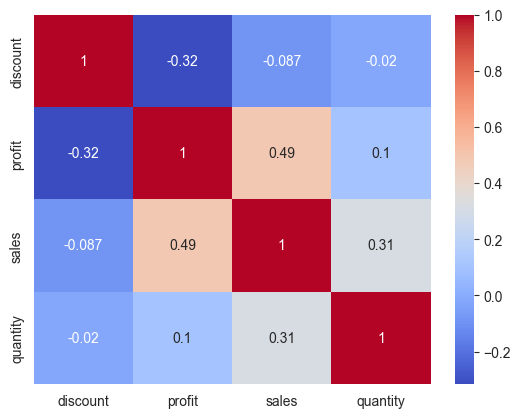

In [29]:
correlation = df[['discount', 'profit', 'sales', 'quantity']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')

## 7. Time Series Forecasting

In [30]:
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
sns.set_palette("husl")  # Colorful palette

# Prepare data
monthly_trend = df.groupby('order_date')['sales'].sum().resample('ME').sum()
monthly_trend_start = df.groupby('order_date')['sales'].sum().resample('MS').sum()

print("Monthly Sales Trend:")
print(monthly_trend.head(10))

Monthly Sales Trend:
order_date
2011-01-31     98898.48886
2011-02-28     91152.15698
2011-03-31    145729.36736
2011-04-30    116915.76418
2011-05-31    146747.83610
2011-06-30    215207.38022
2011-07-31    115510.41912
2011-08-31    207581.49122
2011-09-30    290214.45534
2011-10-31    199071.26404
Freq: ME, Name: sales, dtype: float64


### **Monthly Sales Trend Line**
#### **What this chart shows:**
Three lines on the same chart:

Blue/Violet line (area): Actual monthly sales (raw data)

Green line with squares: 3-month average (smooths out bumps)

Teal line with triangles: 6-month average (even smoother)

What to look for:

Where the lines are going (up = growth, down = decline)

Gaps between lines show sales volatility

Key Insight:
Despite monthly ups and downs, the overall trend is positive (moving averages are rising over time). Our business is growing.

#### **Actionable Takeaway:**

Continue current growth strategies

Investigate what's driving the growth

The trend is your friend – keep doing what's working



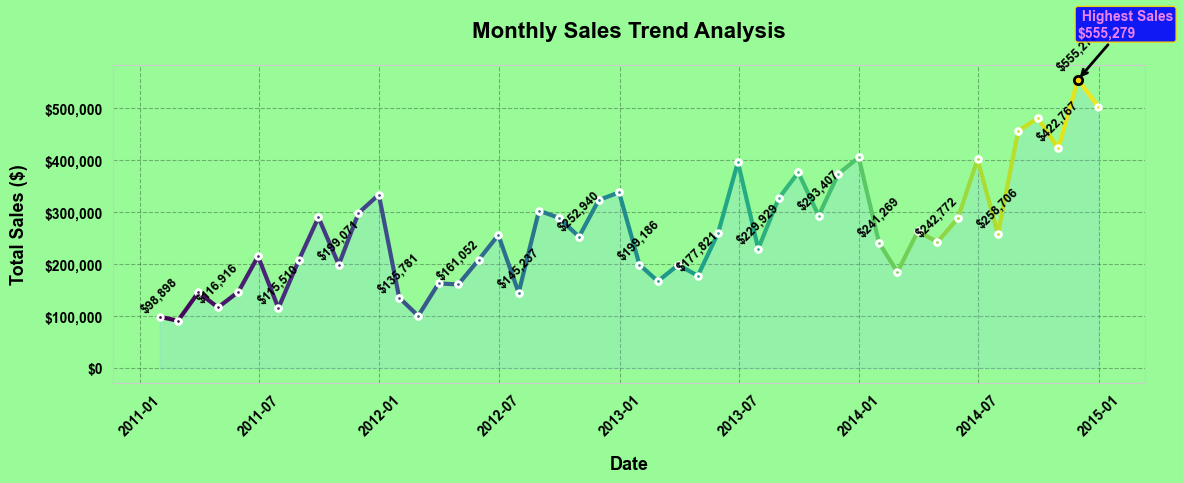

In [51]:
# Create colorful gradient colors for the line
colors_gradient = plt.cm.viridis(np.linspace(0, 1, len(monthly_trend)))

plt.figure(figsize=(12,5), facecolor='palegreen')
ax = plt.gca()
ax.set_facecolor('palegreen')

# Create colorful line with gradient
for i in range(len(monthly_trend) - 1):
    plt.plot(monthly_trend.index[i:i+2], monthly_trend.values[i:i+2], 
             color=colors_gradient[i], linewidth=3, marker='o', 
             markersize=4, markerfacecolor=colors_gradient[i], 
             markeredgecolor='white', markeredgewidth=2)

# Fill area under the line with gradient effect
plt.fill_between(monthly_trend.index, monthly_trend.values, alpha=0.2, color='skyblue')

plt.title('Monthly Sales Trend Analysis', fontsize=16, fontweight='bold', 
          color='black', pad=20)
plt.xlabel('Date', fontsize=13, fontweight='bold', color='black', labelpad=12)
plt.ylabel('Total Sales ($)', fontsize=13, fontweight='bold', color='black', labelpad=12)

# Style ticks
plt.xticks(rotation=45, fontsize=10, fontweight='bold', color='black')
plt.yticks(fontsize=10, fontweight='bold', color='black')

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add grid
plt.grid(True, linestyle='--', alpha=0.3, color='black', axis='both')

# Add value labels on key points
for i, (date, value) in enumerate(monthly_trend.items()):
    if i % 3 == 0 or value == monthly_trend.max():  # Show every 3rd point and max
        plt.text(date, value + (value * 0.02), f'${value:,.0f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold', 
                color='black', rotation=45)

# Highlight maximum point
max_date = monthly_trend.idxmax()
max_value = monthly_trend.max()
plt.plot(max_date, max_value, 'o', markersize=6, 
         markerfacecolor='gold', markeredgecolor='black', 
         markeredgewidth=2, label=f'Peak: ${max_value:,.0f}')
plt.annotate(f' Highest Sales\n${max_value:,.0f}', 
             xy=(max_date, max_value), 
             xytext=(max_date, max_value + (max_value * 0.15)),
             arrowprops=dict(arrowstyle='->', color='black', lw=2),
             fontsize=10, fontweight='bold', color='violet',
             bbox=dict(facecolor='blue', alpha=0.9, edgecolor='gold', 
                      boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()

### **Sales Trend Analysis with Moving Averages**
#### **What this chart shows:**
Three lines on the same chart:

Blue/Violet line (area): Actual monthly sales (raw data)

Green line with squares: 3-month average (smooths out bumps)

Teal line with triangles: 6-month average (even smoother)

What to look for:

Where the lines are going (up = growth, down = decline)

Gaps between lines show sales volatility

Key Insight:
Despite monthly ups and downs, the overall trend is positive (moving averages are rising over time). Our business is growing.

#### **Actionable Takeaway:**

Continue current growth strategies

Investigate what's driving the growth

The trend is your friend – keep doing what's working



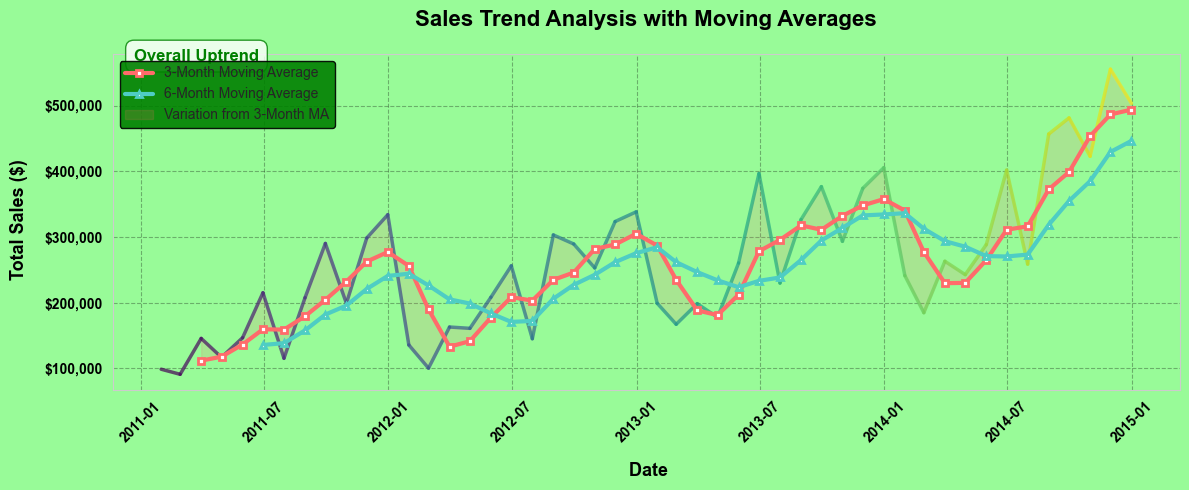

In [52]:
# Calculate moving averages
monthly_trend_sma = monthly_trend.rolling(window=3).mean()
monthly_trend_sma_6 = monthly_trend.rolling(window=6).mean()

plt.figure(figsize=(12,5), facecolor='palegreen')
ax = plt.gca()
ax.set_facecolor('palegreen')

# Plot actual sales with gradient colors
colors_gradient = plt.cm.viridis(np.linspace(0, 1, len(monthly_trend)))
for i in range(len(monthly_trend) - 1):
    plt.plot(monthly_trend.index[i:i+2], monthly_trend.values[i:i+2], 
             color=colors_gradient[i], linewidth=2.5, alpha=0.7)

# Plot moving averages
plt.plot(monthly_trend_sma.index, monthly_trend_sma.values, 
         linewidth=3, label='3-Month Moving Average', 
         color='#FF6B6B', marker='s', markersize=5, 
         markerfacecolor='white', markeredgecolor='#FF6B6B', markeredgewidth=2)

plt.plot(monthly_trend_sma_6.index, monthly_trend_sma_6.values, 
         linewidth=3, label='6-Month Moving Average', 
         color='#4ECDC4', marker='^', markersize=5,
         markerfacecolor='white', markeredgecolor='#4ECDC4', markeredgewidth=2)

# Fill between actual and moving average
plt.fill_between(monthly_trend.index, monthly_trend.values, monthly_trend_sma.values, 
                  alpha=0.15, color='#FF6B6B', label='Variation from 3-Month MA')

plt.title('Sales Trend Analysis with Moving Averages', fontsize=16, fontweight='bold', 
          color='black', pad=20)
plt.xlabel(' Date', fontsize=13, fontweight='bold', color='black', labelpad=12)
plt.ylabel(' Total Sales ($)', fontsize=13, fontweight='bold', color='black', labelpad=12)

# Style ticks
plt.xticks(rotation=45, fontsize=10, fontweight='bold', color='black')
plt.yticks(fontsize=10, fontweight='bold', color='black')

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add grid
plt.grid(True, linestyle='--', alpha=0.3, color='black', axis='both')

# Add legend
plt.legend(loc='upper left', fontsize=10, framealpha=0.9, 
           facecolor='green', edgecolor='black')

# Annotate trend direction
if monthly_trend.values[-1] > monthly_trend.values[0]:
    trend_text = "Overall Uptrend"
    trend_color = 'green'
else:
    trend_text = " Overall Downtrend"
    trend_color = 'red'

plt.text(0.02, 0.98, trend_text, transform=plt.gca().transAxes, 
         fontsize=12, fontweight='bold', color=trend_color,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor=trend_color, 
                  boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

### **Monthly Sales Performance**
### **What this chart shows:**
The same monthly sales data but with exact dollar amounts on top of each bar, plus an average line.

What to look for:

Red dashed line = average sales ($263K)

Green arrows (↑) = months ABOVE average

Gold borders = top 3 best months

Key Insight:

November 2014 was our best month ever ($555K)

February 2011 was our worst month ($91K)

About half the months are above average, half below

#### **Actionable Takeaway:**

Study what made November 2014 successful and replicate it

Learn from February 2011 to avoid repeating poor performance

Set monthly sales targets based on historical patterns

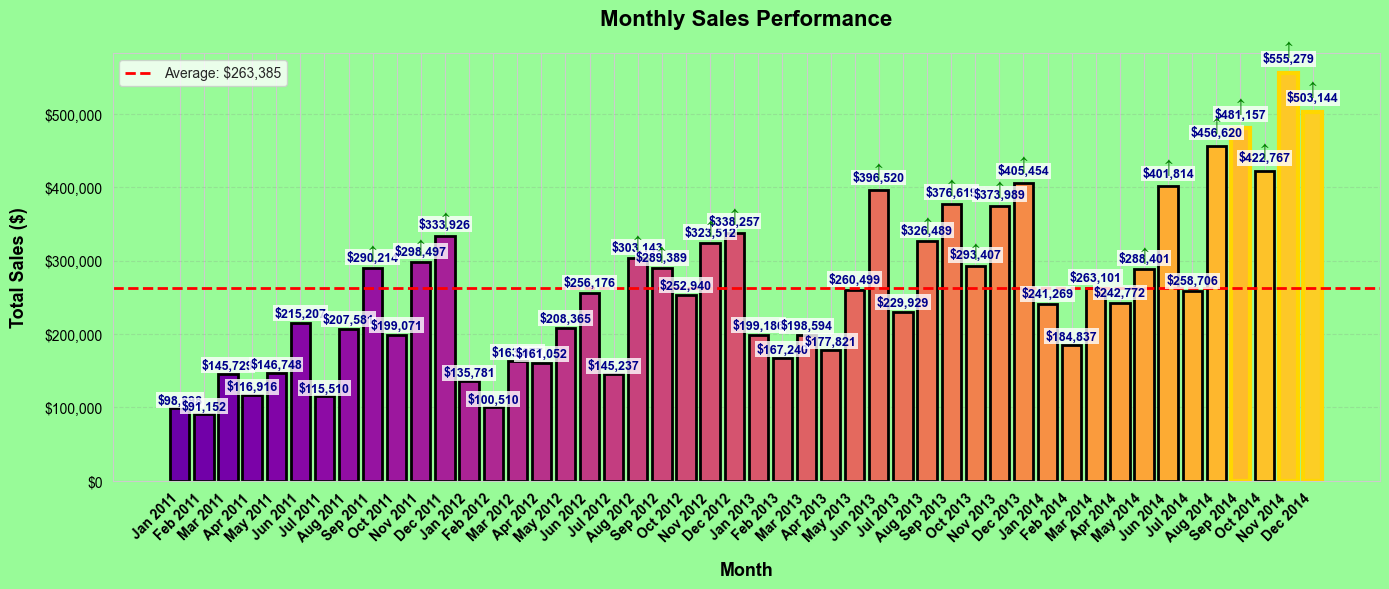

In [53]:
plt.figure(figsize=(14,6), facecolor='palegreen')
ax = plt.gca()
ax.set_facecolor('palegreen')

# Create colorful bars
bar_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(monthly_trend)))
bars = ax.bar(range(len(monthly_trend)), monthly_trend.values, 
              color=bar_colors, edgecolor='black', linewidth=2)

# Customize x-axis labels with month-year format
dates_labels = monthly_trend.index.strftime('%b %Y')
plt.xticks(range(len(monthly_trend)), dates_labels, rotation=45, 
           fontsize=10, fontweight='bold', ha='right', color='black')
plt.yticks(color='black')

plt.title('Monthly Sales Performance', fontsize=16, fontweight='bold', 
          color='black', pad=20)
plt.xlabel('Month', fontsize=13, fontweight='bold', color='black', labelpad=12)
plt.ylabel('Total Sales ($)', fontsize=13, fontweight='bold', color='black', labelpad=12)

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add value labels on top of bars
for bar, value in zip(bars, monthly_trend.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (height * 0.02),
            f'${value:,.0f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold', color='darkblue',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# Highlight top 3 months
top_3_indices = monthly_trend.nlargest(3).index
for bar, date in zip(bars, monthly_trend.index):
    if date in top_3_indices:
        bar.set_edgecolor('gold')
        bar.set_linewidth(3)

# Add performance summary
avg_sales = monthly_trend.mean()
ax.axhline(y=avg_sales, color='red', linestyle='--', linewidth=2, 
           label=f'Average: ${avg_sales:,.0f}')

# Annotate above average months
above_avg = monthly_trend[monthly_trend > avg_sales]
for date in above_avg.index:
    idx = monthly_trend.index.get_loc(date)
    ax.text(idx, monthly_trend[date] + (monthly_trend[date] * 0.05), 
            '↑', ha='center', fontsize=14, fontweight='bold', color='green')

plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.2, color='gray', axis='y')
plt.tight_layout()
plt.show()

#### **Monthly Sales Heatmap (Calendar View)**
#### **What this chart shows:**
A calendar-style view of sales intensity. Darker/redder cells = higher sales. Lighter/yellow cells = lower sales.

What to look for:

Dark red cells = best months

Light yellow cells = worst months

Look for patterns across years

Key Insight:
The darkest cells appear in September, November, and December across multiple years – this is a consistent pattern, not a one-time event.

#### **Actionable Takeaway:**
This is our most actionable chart for planning. We can now predict with confidence that Q4 (October-December) will be our strongest period every year. Plan staffing, inventory, and marketing accordingly.

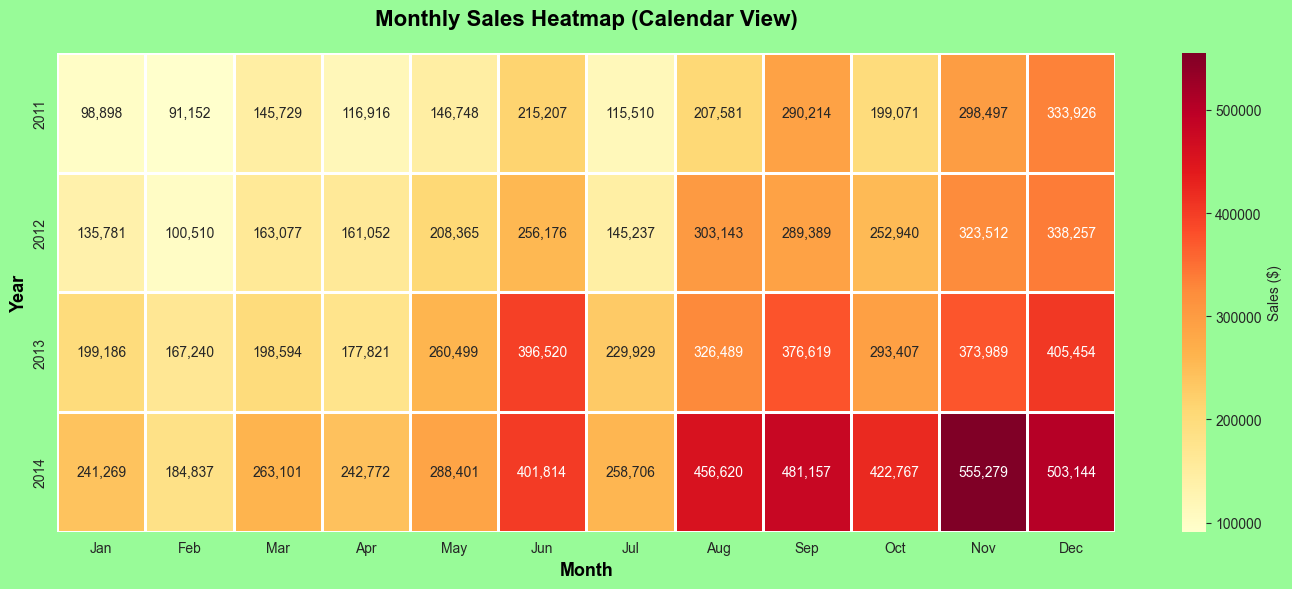

In [54]:
# Prepare data for heatmap
monthly_trend_heatmap = df.groupby([df['order_date'].dt.year, df['order_date'].dt.month])['sales'].sum().unstack()
monthly_trend_heatmap.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(14,6), facecolor='palegreen')
sns.heatmap(monthly_trend_heatmap, annot=True, fmt=',.0f', cmap='YlOrRd', 
            linewidths=2, linecolor='white', cbar_kws={'label': 'Sales ($)'})
plt.title('Monthly Sales Heatmap (Calendar View)', fontsize=16, fontweight='bold', 
          color='black', pad=20)
plt.xlabel('Month', fontsize=13, fontweight='bold', color='black')
plt.ylabel('Year', fontsize=13, fontweight='bold', color='black')
plt.tight_layout()
plt.show()

In [35]:
print(" SALES TREND SUMMARY")
print("="*60)
print(f" Total Sales: ${monthly_trend.sum():,.2f}")
print(f"Average Monthly Sales: ${monthly_trend.mean():,.2f}")
print(f"Highest Sales Month: {monthly_trend.idxmax().strftime('%B %Y')} (${monthly_trend.max():,.2f})")
print(f"Lowest Sales Month: {monthly_trend.idxmin().strftime('%B %Y')} (${monthly_trend.min():,.2f})")
print(f"Standard Deviation: ${monthly_trend.std():,.2f}")
print(f" Growth Trend: {'Positive' if monthly_trend.values[-1] > monthly_trend.values[0] else 'Negative'}")
print(f" Best Month: {monthly_trend.idxmax().strftime('%B %Y')}")
print(f" Worst Month: {monthly_trend.idxmin().strftime('%B %Y')}")
print("="*60)

 SALES TREND SUMMARY
 Total Sales: $12,642,501.91
Average Monthly Sales: $263,385.46
Highest Sales Month: November 2014 ($555,279.03)
Lowest Sales Month: February 2011 ($91,152.16)
Standard Deviation: $113,883.49
 Growth Trend: Positive
 Best Month: November 2014
 Worst Month: February 2011


## SUMMARY


# Superstore Sales Analysis: Executive Summary & Recommendations

## Executive Summary

The analysis of the Superstore’s 2011-2014 sales data reveals a business with a strong, positive growth trajectory but with significant opportunities to optimize marketing, inventory, and pricing strategies, especially regarding discounts.

The single most critical finding is that November and December consistently outperform all other months, representing the peak holiday shopping season. However, the data also shows a clear and strong negative correlation between discounts and profit, indicating that aggressive discounting is eroding the bottom line. To maximize profitability, the Superstore should focus its resources on high-opportunity periods (Q4), high-value customer segments (Home Office), and high-margin product categories (Technology), while implementing a more disciplined and strategic approach to discounts.

## Key Performance Summaries

### 1. Time-Based Performance (Best Times to Advertise)

- **Monthly Trend:** Sales are highly seasonal. September, November, and December consistently show the highest sales volumes across all four years. February is the slowest month every year.
- **Best Months for Advertising:** November and December are the undisputed peak months. However, to fully capitalize on this, marketing campaigns should begin ramping up in **September** to build momentum for the holiday season.
- **Best Day of the Week:** Friday is the busiest day for orders, with significantly more transactions than any other day. Sunday is the slowest.

### 2. Product and Category Performance

- **Most Profitable Category:** Technology leads with a total profit of $663,778.73, followed by Office Supplies ($518,473.83).
- **Top-Selling Products:** Smartphones dominate the top-selling list. The Apple Smart Phone, Full Size is the single best-selling product, with total sales of $86,935.78.
- **Loss-Making Products:** Several high-tech items are significant loss-makers. The Cubify CubeX 3D Printer Double Head Print is the most unprofitable product, with a total loss of -$9,239.97.

### 3. Customer Segment and Geography

- **Most Profitable Segment:** Home Office customers have the highest average profit margin at 5.29%, making them the most valuable customer group per dollar of sales.
- **Top Country:** The United States is the largest market, generating substantially more sales than any other country.

### 4. Correlation and Pricing Analysis

- **Discount vs. Profit:** There is a moderate negative correlation (-0.44) between discounts and profit. This indicates that higher discounts are consistently associated with lower profits, confirming that current discounting practices are often counterproductive.

## Actionable Recommendations

### A. Marketing & Promotions (When to Spend)

1.  **Front-Load Holiday Marketing:** Do not wait for November. Launch major holiday marketing campaigns in September to build early awareness and capture the pre-holiday spending that begins in October.
2.  **Create "Friday Flash Sales":** Since Friday is the peak day for orders, introduce weekly "Friday Flash Sales" with time-limited offers. Email these promotions to customers on Thursday evening or Friday morning to maximize impact.
3.  **Combat Slow Periods:** To boost the slow month of February, create a "February Flash Sale" or a "Winter Clearance" event. This can help generate cash flow and move inventory during a naturally slow period.

### B. Inventory & Product Strategy (What to Sell)

1.  **Stock Up for Q4:** Based on the clear historical trend, aggressively increase inventory levels for all products, especially Technology items and top-selling smartphones, by mid-September to meet the Q4 demand surge.
2.  **Re-evaluate Loss-Making Products:** Conduct a formal review of the top 10 loss-making products, starting with the 3D printer and various smart phone models. For each, decide to discontinue, renegotiate supplier costs, or bundle them with profitable items to move inventory without further hurting margins.
3.  **Bundle Top Sellers:** Create product bundles that pair less popular items with the top-selling smartphones (e.g., "Buy an Apple Smart Phone, get a discounted case and screen protector"). This increases average order value and moves slower inventory.

### C. Pricing & Discount Strategy (How to Price)

1.  **Reduce High Discounts:** The -0.44 correlation is a strong signal. Implement a new policy limiting discounts to a maximum of 15-20% for most products. Reserve deeper discounts only for strategic purposes like inventory clearance at the end of a season.
2.  **Test Discount "Sweet Spots":** Run A/B tests with different discount levels (e.g., 5%, 10%, 15%) on a selection of products to find the level that maximizes profit, not just sales volume.
3.  **Focus on Value, Not Price:** Shift marketing messaging for the Home Office segment (your most profitable group) from price discounts to value propositions like durability, productivity features, and time-saving benefits.

### D. Customer Targeting (Who to Focus On)

1.  **Develop a "Home Office Pro" Campaign:** Create a dedicated marketing campaign and loyalty program specifically for the Home Office segment, offering perks like free expedited shipping, early access to new tech products, and educational content on productivity.
2.  **Re-engage Corporate Accounts:** While less profitable per sale than Home Office, Corporate customers represent steady, large-volume orders. Develop a "Corporate Perks" program focused on bulk-order efficiencies and consolidated billing to improve their profit margin.

## Conclusion

This comprehensive analysis of the Superstore's sales data from 2011 to 2014 provides a clear roadmap for data-driven decision-making. The findings confirm that while the business is on a positive growth trajectory, there are significant opportunities to enhance profitability by strategically reallocating resources away from ineffective practices.

**The most impactful insight** is the strong negative correlation between discounts and profits (-0.44). This challenges the notion that aggressive price reductions are a reliable growth strategy and instead points to the need for a more disciplined, value-based pricing model.

Conversely, the analysis identifies clear, repeatable patterns that can be leveraged for success:

1.  **Seasonality as a Strategic Asset:** The consistent sales peaks in September, November, and December, with Friday as the peak day, provide a reliable, predictable framework for timing marketing campaigns, managing inventory, and scheduling promotions.

2.  **Profit Drivers are Clear:** The Technology category and the Home Office customer segment are the undisputed profit leaders. Focusing marketing efforts and product development on these areas will yield the highest returns on investment.

3.  **Inventory Optimization is Possible:** By spotlighting top-selling products like the Apple Smart Phone and major loss-makers like the Cubify CubeX 3D Printer, the analysis provides the necessary data to make decisive choices about product discontinuation, supplier renegotiation, and strategic bundling.

**Final Recommendation:**

The Superstore should pivot from a broad, discount-driven sales strategy to a focused, value-driven profitability strategy. This means aligning marketing, inventory, and pricing decisions with the concrete seasonal and customer-segment insights derived from its own sales data. By implementing the recommended actions—such as launching September holiday campaigns, running Friday Flash Sales, stocking up for Q4, and re-evaluating loss-making products—the Superstore can protect its margins, increase customer lifetime value, and sustain its positive growth trajectory for years to come.